In [45]:
%run ../scripts/notebook_settings_lean.py
from scipy import stats
from horizonplot import horizonplot
from chromwindow import window
import zarr
import allel
pd.options.display.float_format = '{:10,.3g}'.format 

Checking outcome differences between using close and distant sources.

In [46]:
meta_data_samples_sci = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")

c_r_g_df = pd.read_csv("../steps/rfmix_stats_df/call_recomb_genes.txt")
c_r_g_df

,chrom,start,callable_frac,end,cM,end_cM,average_cM_window,genes,genic
0,chr1,0,0.795,100000,0,0.36,3.6e-06,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True
1,chr1,100000,0.89,200000,0.36,0.477,1.16e-06,"['TTLL10', 'TTLL10', 'TTLL10', 'TTLL10', 'TTLL...",True
2,chr1,200000,0.919,300000,0.477,0.547,7.05e-07,"['B3GALT6', 'C1QTNF12', 'UBE2J2', 'UBE2J2', 'U...",True
3,chr1,300000,0.878,400000,0.547,0.626,7.94e-07,"['DVL1', 'DVL1', 'DVL1', 'MXRA8', 'MXRA8', 'MX...",True
4,chr1,400000,0.485,500000,0.626,1.37,7.4e-06,"['VWA1', 'TMEM240', 'SSU72']",True
...,...,...,...,...,...,...,...,...,...
27377,chrX,143200000,0.67,143300000,127,127,2.56e-07,"['TMLHE', 'TMLHE', 'TMLHE', 'TMLHE', 'TMLHE']",True
27378,chrX,143300000,0.905,143400000,127,127,3.37e-07,"['TMLHE', 'TMLHE', 'TMLHE', 'TMLHE']",True
27379,chrX,143400000,0.789,143500000,127,127,2.8e-07,['SPRY3'],True
27380,chrX,143500000,0.836,143600000,127,127,7.53e-07,['VAMP7'],True


In [47]:
result_order = ['Selous, Tanzania', 'Mikumi, Tanzania', 'Udzungwa, Tanzania', 'Ruaha, Tanzania',
       'Tarangire, Tanzania', 'Arusha, Tanzania', 'Ngorongoro, Tanzania', 'Gombe, Tanzania', 
             'Lake Manyara, Tanzania', 'Serengeti, Tanzania', 'Gog Woreda, Gambella region, Ethiopia',
               'Niokolo-Koba, Senegal', 'Filoha, Ethiopia', 'Dendro Park, Zambia', 'Chunga, Zambia']

In [48]:
o_l, f_c, m_c, species_l = [], [], [], []
for o in result_order:
    o_l.append(o)
    f_c.append(len(meta_data_samples_sci.loc[(meta_data_samples_sci.Origin == o) & (meta_data_samples_sci.Sex == "F")]))
    m_c.append(len(meta_data_samples_sci.loc[(meta_data_samples_sci.Origin == o) & (meta_data_samples_sci.Sex == "M")]))
    species_l.append(meta_data_samples_sci.loc[(meta_data_samples_sci.Origin == o)].Species.iloc[0])

In [49]:
pd.DataFrame({"Origin": o_l, "Female count": f_c, "Male count": m_c, "species": species_l})

,Origin,Female count,Male count,species
0,"Selous, Tanzania",1,2,cynocephalus
1,"Mikumi, Tanzania",13,25,cynocephalus
2,"Udzungwa, Tanzania",3,2,cynocephalus
3,"Ruaha, Tanzania",4,2,cynocephalus
4,"Tarangire, Tanzania",4,3,anubis
5,"Arusha, Tanzania",2,2,anubis
6,"Ngorongoro, Tanzania",5,1,anubis
7,"Gombe, Tanzania",10,7,anubis
8,"Lake Manyara, Tanzania",15,4,anubis
9,"Serengeti, Tanzania",7,7,anubis


In [50]:
rfmix_path = "../steps/rfmix_gen100/tanzania_focus/"

df_l = []
chroms = ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_tanz = pd.concat(df_l)
mean_window_df_tanz = window_df_tanz.groupby(["chrom", "individual", "start", "end"]).mean().reset_index()
tanz_olives = meta_data_samples_sci.loc[meta_data_samples_sci.C_origin == "Anubis, Tanzania"].PGDP_ID
mean_window_df_tanz_olive = mean_window_df_tanz.loc[mean_window_df_tanz.individual.isin(tanz_olives)]

In [8]:
meta_data_samples_sci.Origin.unique()

array(['Mikumi, Tanzania', 'Aberdare, Kenya', 'Chunga, Zambia', 'captive',
       'Awash, Ethiopia', 'Serengeti, Tanzania', 'Arusha, Tanzania',
       'Ngorongoro, Tanzania', 'Ruaha, Tanzania', 'Gombe, Tanzania',
       'Udzungwa, Tanzania', 'Mahale, Tanzania', 'Katavi, Tanzania',
       'Selous, Tanzania', 'Lake Manyara, Tanzania',
       'Tarangire, Tanzania', 'Niokolo-Koba, Senegal',
       'Issa Valley, Tanzania', 'Dendro Park, Zambia', 'Filoha, Ethiopia',
       'Gog Woreda, Gambella region, Ethiopia'], dtype=object)

In [9]:
meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Mahale, Tanzania"]

,PGDP_ID,Provider_ID,Provider,Genus,Species,Origin,Sex,address,longitude,latitude,callset_index,C_origin,x_missing
39,PD_0228,01MNM1300916,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",M,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,39,"Cynocephalus, Western Tanzania",0.0151
40,PD_0229,02MNM1300916,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",M,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,40,"Cynocephalus, Western Tanzania",0.0157
41,PD_0230,04MNM1300916,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",M,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,41,"Cynocephalus, Western Tanzania",0.0156
42,PD_0231,09MNM1011016,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",M,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,42,"Cynocephalus, Western Tanzania",0.0148
43,PD_0232,14MNF1041016,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",F,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,43,"Cynocephalus, Western Tanzania",0.0081
103,PD_0658,79 / 08MNM1011016,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",M,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,103,"Cynocephalus, Western Tanzania",0.0157
104,PD_0659,81 / 13MNF1031016,Knauf/Chuma/Roos,Papio,cynocephalus,"Mahale, Tanzania",F,"Mahale National Park, Kigoma, Western Zone, Ta...",29.9,-6.2,104,"Cynocephalus, Western Tanzania",0.00815


In [10]:
window_df_tanz.chrom.unique()

array(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8',
       'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15',
       'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'all_chrX',
       'female_chrX', 'female_ref_chrX'], dtype=object)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

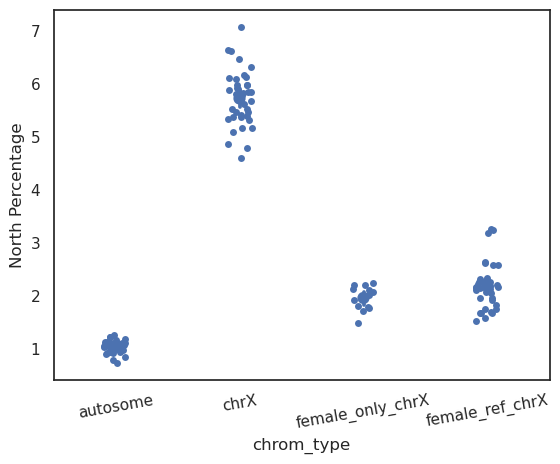

In [11]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Mikumi, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

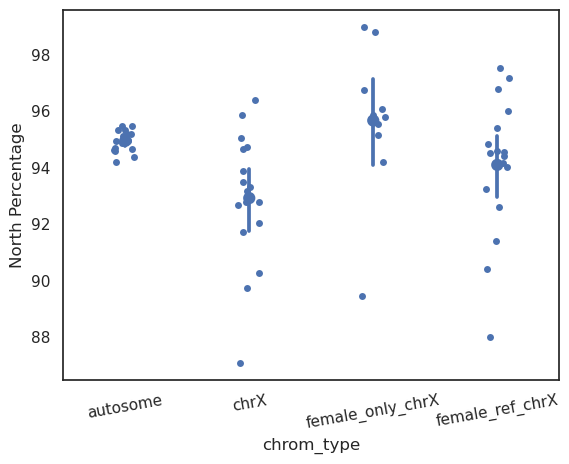

In [56]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Gombe, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

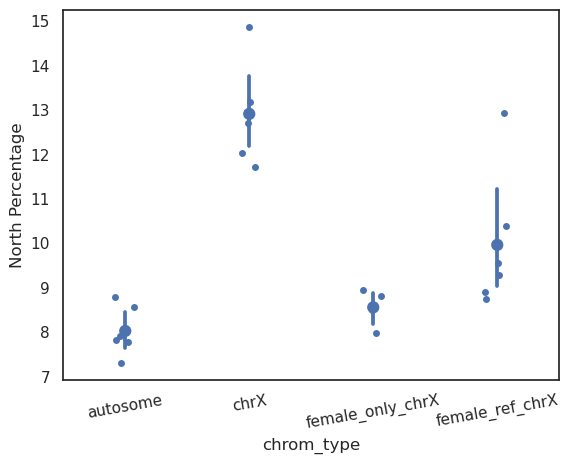

In [12]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Ruaha, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

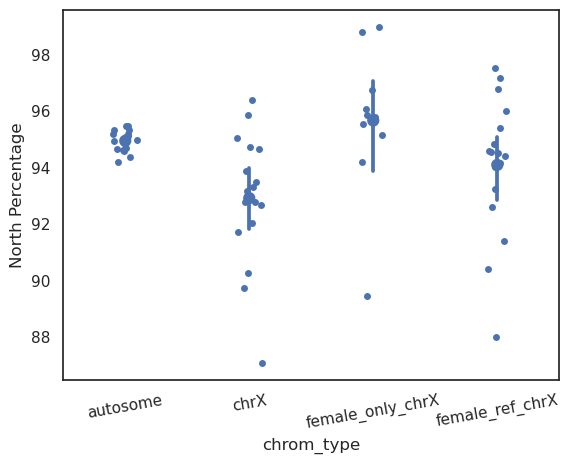

In [13]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Gombe, Tanzania"].PGDP_ID
window_picked = window_df_tanz.loc[window_df_tanz.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

In [14]:
rfmix_path = "../steps/rfmix_gen100/tanzania_close_focus/"

df_l = []
chroms = ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_tanz_close = pd.concat(df_l)
mean_window_df_tanz_close = window_df_tanz_close.groupby(["chrom", "individual", "start", "end"]).mean().reset_index()

In [15]:
meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Selous, Tanzania"].PGDP_ID

46    PD_0235
47    PD_0236
48    PD_0237
Name: PGDP_ID, dtype: object

In [16]:
window_df_tanz_close.loc[window_df_tanz_close.individual == "PD_0238"]

,chrom,individual,haplotype,start,end,north_sum
152250,chr1,PD_0238,0,0,100000,99840
152251,chr1,PD_0238,0,100000,200000,100000
152252,chr1,PD_0238,0,200000,300000,100000
152253,chr1,PD_0238,0,300000,400000,100000
152254,chr1,PD_0238,0,400000,500000,100000
...,...,...,...,...,...,...
97711,female_ref_chrX,PD_0238,1,143200000,143300000,100000
97712,female_ref_chrX,PD_0238,1,143300000,143400000,100000
97713,female_ref_chrX,PD_0238,1,143400000,143500000,100000
97714,female_ref_chrX,PD_0238,1,143500000,143600000,100000


(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

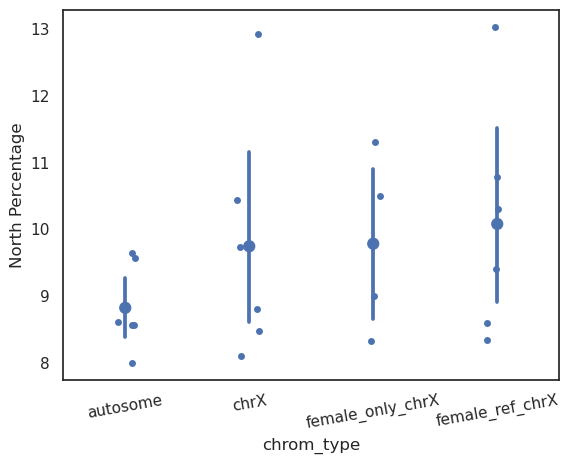

In [17]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Ruaha, Tanzania"].PGDP_ID
window_picked = window_df_tanz_close.loc[window_df_tanz_close.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'autosome'),
  Text(1, 0, 'chrX'),
  Text(2, 0, 'female_only_chrX'),
  Text(3, 0, 'female_ref_chrX')])

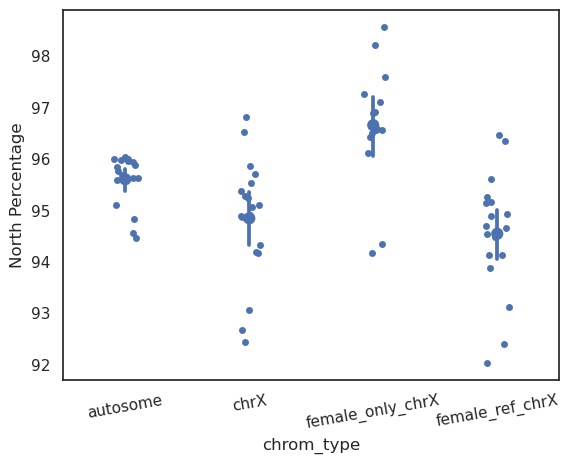

In [18]:
picked_samples = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == "Lake Manyara, Tanzania"].PGDP_ID
window_picked = window_df_tanz_close.loc[window_df_tanz_close.individual.isin(picked_samples)].copy()
window_picked["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in window_picked.chrom]
picked_mean_north = window_picked.groupby(["chrom_type", "individual"])[["north_sum"]].mean().reset_index()
picked_mean_north["North Percentage"] = picked_mean_north.north_sum/1000
sns.stripplot(picked_mean_north, x="chrom_type", y="North Percentage")
sns.pointplot(picked_mean_north, x="chrom_type", y="North Percentage", join=False)
plt.xticks(rotation=10)

In [19]:
from scipy import stats
# Distant references
window_df_chrX = window_df_tanz.loc[window_df_tanz["chrom"].isin(["all_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index()
window_df_chrX["chrom"] = "chrX"
window_df_chrX = window_df_chrX.merge(c_r_g_df, on=["chrom", "start", "end"])
window_df_aut = window_df_tanz.loc[~window_df_tanz["chrom"].isin(["all_chrX", "female_chrX", "female_ref_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index().merge(c_r_g_df, on=["chrom", "start"])
# Close references
window_df_chrX_close = window_df_tanz_close.loc[window_df_tanz_close["chrom"].isin(["all_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index()
window_df_chrX_close["chrom"] = "chrX"
window_df_chrX_close = window_df_chrX_close.merge(c_r_g_df, on=["chrom", "start", "end"])
window_df_aut_close = window_df_tanz_close.loc[~window_df_tanz_close["chrom"].isin(["all_chrX", "female_chrX", "female_ref_chrX"])].groupby(["chrom", "individual", "start", "end"])[["north_sum"]].mean().reset_index().merge(c_r_g_df, on=["chrom", "start"])

In [23]:
o_l, i_l, admixture_l, admixture_close_l, admixture_chrX_l, admixture_close_chrX_l = [], [], [], [], [], []
aut_corr_l, chrX_corr_l = [], []
for o in ['Arusha, Tanzania',
       'Ngorongoro, Tanzania', 'Ruaha, Tanzania', 'Gombe, Tanzania',
       'Udzungwa, Tanzania',
       'Selous, Tanzania', 'Lake Manyara, Tanzania',
       'Tarangire, Tanzania']:
    print(o)
    ids = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == o].PGDP_ID
    for i in ids:
        ind_window_all_chrX = window_df_chrX.loc[(window_df_chrX.individual == i) &
                                           (window_df_chrX.callable_frac > 0.75)]
        ind_window_all = window_df_aut.loc[(window_df_aut.individual == i)&
                                           (window_df_aut.callable_frac > 0.75)]
        ind_window_close_chrX = window_df_chrX_close.loc[(window_df_chrX_close.individual == i)&
                                           (window_df_chrX_close.callable_frac > 0.75)]
        ind_window_close = window_df_aut_close.loc[(window_df_aut_close.individual == i)&
                                           (window_df_aut_close.callable_frac > 0.75)]
        o_l.append(o), i_l.append(i)
        if o in ['Ruaha, Tanzania', 'Selous, Tanzania', 'Udzungwa, Tanzania']:
            admixture_l.append(ind_window_all.north_sum.mean()/1000)
            admixture_close_l.append(ind_window_close.north_sum.mean()/1000)
            admixture_chrX_l.append(ind_window_all_chrX.north_sum.mean()/1000)
            admixture_close_chrX_l.append(ind_window_close_chrX.north_sum.mean()/1000)
            aut_corr_l.append(stats.pearsonr(ind_window_all.north_sum, ind_window_close.north_sum)[0])
            chrX_corr_l.append(stats.pearsonr(ind_window_all_chrX.north_sum, ind_window_close_chrX.north_sum)[0])
        else:
            admixture_l.append(100-ind_window_all.north_sum.mean()/1000)
            admixture_close_l.append(100-ind_window_close.north_sum.mean()/1000)
            admixture_chrX_l.append(100-ind_window_all_chrX.north_sum.mean()/1000)
            admixture_close_chrX_l.append(100-ind_window_close_chrX.north_sum.mean()/1000)
            aut_corr_l.append(stats.pearsonr(ind_window_all.north_sum, ind_window_close.north_sum)[0])
            chrX_corr_l.append(stats.pearsonr(ind_window_all_chrX.north_sum, ind_window_close_chrX.north_sum)[0])

Arusha, Tanzania
Ngorongoro, Tanzania
Ruaha, Tanzania
Gombe, Tanzania
Selous, Tanzania


ValueError: x and y must have the same length.

In [36]:
for o in ['Udzungwa, Tanzania',
       'Selous, Tanzania']:
    print(o)
    ids = meta_data_samples_sci.loc[meta_data_samples_sci.Origin == o].PGDP_ID
    for i in ids:
        print(i)
        if i in ["PD_0225"]:
            continue
        ind_window_all_chrX = window_df_chrX.loc[(window_df_chrX.individual == i) &
                                           (window_df_chrX.callable_frac > 0.75)]
        ind_window_all = window_df_aut.loc[(window_df_aut.individual == i)&
                                           (window_df_aut.callable_frac > 0.75)]
        ind_window_close_chrX = window_df_chrX_close.loc[(window_df_chrX_close.individual == i)&
                                           (window_df_chrX_close.callable_frac > 0.75)]
        ind_window_close = window_df_aut_close.loc[(window_df_aut_close.individual == i)&
                                           (window_df_aut_close.callable_frac > 0.75)]
        o_l.append(o), i_l.append(i)
        if o in ['Selous, Tanzania']:
            admixture_l.append(ind_window_all.north_sum.mean()/1000)
            admixture_close_l.append(ind_window_close.north_sum.mean()/1000)
            admixture_chrX_l.append(ind_window_all_chrX.north_sum.mean()/1000)
            admixture_close_chrX_l.append(ind_window_close_chrX.north_sum.mean()/1000)
            aut_corr_l.append(stats.pearsonr(ind_window_all.north_sum, ind_window_close.north_sum)[0])
            chrX_corr_l.append(stats.pearsonr(ind_window_all_chrX.north_sum, ind_window_close_chrX.north_sum)[0])
        else:
            admixture_l.append(100-ind_window_all.north_sum.mean()/1000)
            admixture_close_l.append(100-ind_window_close.north_sum.mean()/1000)
            admixture_chrX_l.append(100-ind_window_all_chrX.north_sum.mean()/1000)
            admixture_close_chrX_l.append(100-ind_window_close_chrX.north_sum.mean()/1000)
            aut_corr_l.append(stats.pearsonr(ind_window_all.north_sum, ind_window_close.north_sum)[0])
            chrX_corr_l.append(stats.pearsonr(ind_window_all_chrX.north_sum, ind_window_close_chrX.north_sum)[0])

Udzungwa, Tanzania
PD_0223
PD_0224
PD_0225
PD_0226
PD_0227
Selous, Tanzania
PD_0235


ValueError: x and y must have the same length.

In [44]:
len(ind_window_all["chrom"].unique()), i

(15, 'PD_0235')

In [ ]:
aut_df.north_sum_y.mean()/1000

In [ ]:
window_df_aut_close

In [ ]:
ind_window_all_aut

In [ ]:
ind_window_all_aut.loc[ind_window_all_aut["chrom"].isin(window_df_aut_close.loc[window_df_aut_close.individual == i]["chrom"].unique())]

In [ ]:
# Selous ind check
window_df_aut.loc[window_df_aut.individual == "PD_0235"]["chrom"].unique()

In [ ]:
window_df_aut_close.loc[window_df_aut_close.individual == "PD_0235"]["chrom"].unique()

In [ ]:
correlation_df = pd.DataFrame({"Origin": o_l, "Distant autosomal MPA": admixture_l,
              "Close autosomal MPA": admixture_close_l, "Autosomal Correlation": aut_corr_l,
              "Distant ChrX MPA": admixture_chrX_l, "Close ChrX MPA": admixture_close_chrX_l,
              "ChrX Correlation": chrX_corr_l})

In [ ]:
correlation_df.groupby(["Origin"]).mean().reset_index()